# Phase 2 — Collecte & Audit des Données

---
**Objectif :** Charger tous les datasets, documenter leur structure (Data Dictionary), puis réaliser un audit qualité complet (valeurs manquantes, doublons, types, statistiques).

---

## 0. Configuration & Imports

In [2]:
# ============================================================
# IMPORTS — bibliothèques standard pour l'analyse de données
# ============================================================
import pandas as pd          # Manipulation de DataFrames
import numpy as np           # Calculs numériques
import matplotlib.pyplot as plt  # Visualisation de base
import seaborn as sns        # Visualisation avancée
import os                    # Gestion des chemins de fichiers
import warnings


# Style global des graphiques
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')



Imports OK


In [4]:
# ============================================================
# CHEMINS DES DONNÉES
# Adaptez ces chemins à votre structure de dossiers locale.
# ============================================================

# Racine commune
DATA_ROOT = r"C:\Users\AORUS\Documents\ENSIAS 2A\projetDDD"  # <-- modifiez ce chemin si nécessaire

# --- Olist ---
OLIST_DIR = os.path.join(DATA_ROOT, "Brazilian E-Commerce Public Dataset by Olist/")

# --- Instacart ---
INSTACART_DIR = os.path.join(DATA_ROOT, "Instacart Market Basket Analysis/")

# --- Amazon ---
AMAZON_DIR = os.path.join(DATA_ROOT, "Amazon Product Reviews Dataset/")

print("Chemins configurés")
print(f"  Olist     : {OLIST_DIR}")
print(f"  Instacart : {INSTACART_DIR}")
print(f"  Amazon    : {AMAZON_DIR}")

Chemins configurés
  Olist     : C:\Users\AORUS\Documents\ENSIAS 2A\projetDDD\Brazilian E-Commerce Public Dataset by Olist/
  Instacart : C:\Users\AORUS\Documents\ENSIAS 2A\projetDDD\Instacart Market Basket Analysis/
  Amazon    : C:\Users\AORUS\Documents\ENSIAS 2A\projetDDD\Amazon Product Reviews Dataset/


---
## 1. Chargement des Données
### 1.1 Dataset Olist (Brazilian E-Commerce)

In [5]:
# ============================================================
# CHARGEMENT OLIST
# 6 tables interconnectées décrivant le cycle complet d'une commande
# ============================================================

# Table clients : informations géographiques et identifiants
olist_customers = pd.read_csv(os.path.join(OLIST_DIR, 'olist_customers_dataset.csv'))

# Table commandes : statuts et dates clés de chaque commande
olist_orders = pd.read_csv(os.path.join(OLIST_DIR, 'olist_orders_dataset.csv'))

# Table articles commandés : produits, quantités, prix, frais de port
olist_order_items = pd.read_csv(os.path.join(OLIST_DIR, 'olist_order_items_dataset.csv'))

# Table paiements : méthode et montants de paiement
olist_payments = pd.read_csv(os.path.join(OLIST_DIR, 'olist_order_payments_dataset.csv'))

# Table avis clients : notes et commentaires post-livraison
olist_reviews = pd.read_csv(os.path.join(OLIST_DIR, 'olist_order_reviews_dataset.csv'))

# Table produits : catégorie, dimensions, poids
olist_products = pd.read_csv(os.path.join(OLIST_DIR, 'olist_products_dataset.csv'))

# Table traduction des catégories : noms en anglais
olist_category_translation = pd.read_csv(os.path.join(OLIST_DIR, 'product_category_name_translation.csv'))

print(" Olist chargé")
print(f"  Customers  : {olist_customers.shape}")
print(f"  Orders     : {olist_orders.shape}")
print(f"  Items      : {olist_order_items.shape}")
print(f"  Payments   : {olist_payments.shape}")
print(f"  Reviews    : {olist_reviews.shape}")
print(f"  Products   : {olist_products.shape}")

 Olist chargé
  Customers  : (99441, 5)
  Orders     : (99441, 8)
  Items      : (112650, 7)
  Payments   : (103886, 5)
  Reviews    : (99224, 7)
  Products   : (32951, 9)


### 1.2 Dataset Instacart

In [6]:
# ============================================================
# CHARGEMENT INSTACART
# Données d'achats de type grocery — historique riche par client
# ============================================================

# Table commandes : métadonnées (heure, jour, délai depuis dernier achat)
insta_orders = pd.read_csv(os.path.join(INSTACART_DIR, 'orders.csv'))

# Table produits commandés antérieurement (données d'entraînement)
insta_order_products_prior = pd.read_csv(os.path.join(INSTACART_DIR, 'order_products__prior.csv'))

# Catalogue produits avec leurs rayons
insta_products = pd.read_csv(os.path.join(INSTACART_DIR, 'products.csv'))

# Rayons (aisles)
insta_aisles = pd.read_csv(os.path.join(INSTACART_DIR, 'aisles.csv'))

# Départements
insta_departments = pd.read_csv(os.path.join(INSTACART_DIR, 'departments.csv'))

print(" Instacart chargé")
print(f"  Orders               : {insta_orders.shape}")
print(f"  Order Products Prior : {insta_order_products_prior.shape}")
print(f"  Products             : {insta_products.shape}")
print(f"  Aisles               : {insta_aisles.shape}")
print(f"  Departments          : {insta_departments.shape}")

 Instacart chargé
  Orders               : (3421083, 7)
  Order Products Prior : (32434489, 4)
  Products             : (49688, 4)
  Aisles               : (134, 2)
  Departments          : (21, 2)


### 1.3 Dataset Amazon Reviews

In [8]:
# ============================================================
# CHARGEMENT AMAZON REVIEWS
# Avis textuels + notes numériques sur des produits Amazon
# ============================================================

# NOTE : Le fichier peut s'appeler 'amazon_reviews.csv' ou similaire
# Adaptez le nom selon votre téléchargement Kaggle
amazon_reviews = pd.read_csv(os.path.join(AMAZON_DIR, 'amazon_review.csv'))

print(" Amazon Reviews chargé")
print(f"  Reviews : {amazon_reviews.shape}")
print(f"  Colonnes : {list(amazon_reviews.columns)}")

 Amazon Reviews chargé
  Reviews : (4915, 12)
  Colonnes : ['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime', 'day_diff', 'helpful_yes', 'total_vote']


---
## 2. Data Dictionary

> Le Data Dictionary documente chaque colonne : nom, type Python, type sémantique, description métier et valeurs possibles. C'est un livrable obligatoire du projet.

In [10]:
# ============================================================
# FONCTION UTILITAIRE : génère automatiquement un Data Dictionary
# pour un DataFrame donné, avec colonnes, types et aperçu des valeurs
# ============================================================

def build_data_dictionary(df, table_name, descriptions=None):
    """
    Génère un Data Dictionary sous forme de DataFrame.
    
    Paramètres:
        df           : DataFrame à documenter
        table_name   : Nom de la table (str)
        descriptions : dict optionnel {colonne: description métier}
    
    Retourne:
        DataFrame avec colonnes: Colonne, Type_Python, Nb_Valeurs_Uniques,
                                  Pct_Manquants, Exemple_Valeur, Description
    """
    if descriptions is None:
        descriptions = {}
    
    rows = []
    for col in df.columns:
        rows.append({
            'Table'               : table_name,
            'Colonne'             : col,
            'Type_Python'         : str(df[col].dtype),
            'Nb_Valeurs_Uniques'  : df[col].nunique(),
            'Pct_Manquants'       : round(df[col].isnull().mean() * 100, 2),
            'Exemple_Valeur'      : df[col].dropna().iloc[0] if df[col].dropna().shape[0] > 0 else 'N/A',
            'Description'         : descriptions.get(col, '— à documenter —')
        })
    
    return pd.DataFrame(rows)

print(" Fonction build_data_dictionary définie")

 Fonction build_data_dictionary définie


In [11]:
# ============================================================
# DATA DICTIONARY — OLIST CUSTOMERS
# ============================================================

olist_customers_desc = {
    'customer_id'               : 'Identifiant unique de la commande côté client (clé étrangère)',
    'customer_unique_id'        : 'Identifiant unique du client (clé primaire client)',
    'customer_zip_code_prefix'  : 'Code postal du client (5 chiffres)',
    'customer_city'             : 'Ville du client',
    'customer_state'            : 'État brésilien du client (abréviation 2 lettres)'
}

dd_customers = build_data_dictionary(olist_customers, 'olist_customers', olist_customers_desc)
display(dd_customers)

,Table,Colonne,Type_Python,Nb_Valeurs_Uniques,Pct_Manquants,Exemple_Valeur,Description
0,olist_customers,customer_id,str,99441,0.0,06b8999e2fba1a1fbc88172c00ba8bc7,Identifiant unique de la commande côté client ...
1,olist_customers,customer_unique_id,str,96096,0.0,861eff4711a542e4b93843c6dd7febb0,Identifiant unique du client (clé primaire cli...
2,olist_customers,customer_zip_code_prefix,int64,14994,0.0,14409,Code postal du client (5 chiffres)
3,olist_customers,customer_city,str,4119,0.0,franca,Ville du client
4,olist_customers,customer_state,str,27,0.0,SP,État brésilien du client (abréviation 2 lettres)


In [12]:
# ============================================================
# DATA DICTIONARY — OLIST ORDERS
# ============================================================

olist_orders_desc = {
    'order_id'                          : 'Identifiant unique de la commande',
    'customer_id'                       : 'Identifiant client (clé étrangère → olist_customers)',
    'order_status'                      : 'Statut de la commande (delivered, shipped, canceled, etc.)',
    'order_purchase_timestamp'          : 'Date et heure de passage de la commande',
    'order_approved_at'                 : 'Date et heure de validation du paiement',
    'order_delivered_carrier_date'      : 'Date de remise au transporteur',
    'order_delivered_customer_date'     : 'Date de livraison effective au client',
    'order_estimated_delivery_date'     : 'Date de livraison estimée lors de la commande'
}

dd_orders = build_data_dictionary(olist_orders, 'olist_orders', olist_orders_desc)
display(dd_orders)

,Table,Colonne,Type_Python,Nb_Valeurs_Uniques,Pct_Manquants,Exemple_Valeur,Description
0,olist_orders,order_id,str,99441,0.00,e481f51cbdc54678b7cc49136f2d6af7,Identifiant unique de la commande
1,olist_orders,customer_id,str,99441,0.00,9ef432eb6251297304e76186b10a928d,Identifiant client (clé étrangère → olist_cust...
2,olist_orders,order_status,str,8,0.00,delivered,"Statut de la commande (delivered, shipped, can..."
3,olist_orders,order_purchase_timestamp,str,98875,0.00,2017-10-02 10:56:33,Date et heure de passage de la commande
4,olist_orders,order_approved_at,str,90733,0.16,2017-10-02 11:07:15,Date et heure de validation du paiement
5,olist_orders,order_delivered_carrier_date,str,81018,1.79,2017-10-04 19:55:00,Date de remise au transporteur
6,olist_orders,order_delivered_customer_date,str,95664,2.98,2017-10-10 21:25:13,Date de livraison effective au client
7,olist_orders,order_estimated_delivery_date,str,459,0.00,2017-10-18 00:00:00,Date de livraison estimée lors de la commande


In [13]:
# ============================================================
# DATA DICTIONARY — OLIST ORDER ITEMS
# ============================================================

olist_items_desc = {
    'order_id'           : 'Identifiant commande (clé étrangère → olist_orders)',
    'order_item_id'      : 'Numéro de ligne dans la commande (1, 2, 3...)',
    'product_id'         : 'Identifiant produit (clé étrangère → olist_products)',
    'seller_id'          : 'Identifiant vendeur',
    'shipping_limit_date': 'Date limite d\'expédition pour le vendeur',
    'price'              : 'Prix unitaire du produit (BRL)',
    'freight_value'      : 'Frais de livraison pour cet article (BRL)'
}

dd_items = build_data_dictionary(olist_order_items, 'olist_order_items', olist_items_desc)
display(dd_items)

,Table,Colonne,Type_Python,Nb_Valeurs_Uniques,Pct_Manquants,Exemple_Valeur,Description
0,olist_order_items,order_id,str,98666,0.0,00010242fe8c5a6d1ba2dd792cb16214,Identifiant commande (clé étrangère → olist_or...
1,olist_order_items,order_item_id,int64,21,0.0,1,"Numéro de ligne dans la commande (1, 2, 3...)"
2,olist_order_items,product_id,str,32951,0.0,4244733e06e7ecb4970a6e2683c13e61,Identifiant produit (clé étrangère → olist_pro...
3,olist_order_items,seller_id,str,3095,0.0,48436dade18ac8b2bce089ec2a041202,Identifiant vendeur
4,olist_order_items,shipping_limit_date,str,93318,0.0,2017-09-19 09:45:35,Date limite d'expédition pour le vendeur
5,olist_order_items,price,float64,5968,0.0,58.9,Prix unitaire du produit (BRL)
6,olist_order_items,freight_value,float64,6999,0.0,13.29,Frais de livraison pour cet article (BRL)


In [14]:
# ============================================================
# DATA DICTIONARY — OLIST PAYMENTS
# ============================================================

olist_payments_desc = {
    'order_id'             : 'Identifiant commande (clé étrangère)',
    'payment_sequential'   : 'Numéro de séquence (commandes à paiements multiples)',
    'payment_type'         : 'Type de paiement (credit_card, boleto, voucher, debit_card)',
    'payment_installments' : 'Nombre de mensualités choisies par le client',
    'payment_value'        : 'Montant de ce paiement (BRL)'
}

dd_payments = build_data_dictionary(olist_payments, 'olist_payments', olist_payments_desc)
display(dd_payments)

,Table,Colonne,Type_Python,Nb_Valeurs_Uniques,Pct_Manquants,Exemple_Valeur,Description
0,olist_payments,order_id,str,99440,0.0,b81ef226f3fe1789b1e8b2acac839d17,Identifiant commande (clé étrangère)
1,olist_payments,payment_sequential,int64,29,0.0,1,Numéro de séquence (commandes à paiements mult...
2,olist_payments,payment_type,str,5,0.0,credit_card,"Type de paiement (credit_card, boleto, voucher..."
3,olist_payments,payment_installments,int64,24,0.0,8,Nombre de mensualités choisies par le client
4,olist_payments,payment_value,float64,29077,0.0,99.33,Montant de ce paiement (BRL)


In [15]:
# ============================================================
# DATA DICTIONARY — OLIST REVIEWS
# ============================================================

olist_reviews_desc = {
    'review_id'                  : 'Identifiant unique de l\'avis',
    'order_id'                   : 'Identifiant commande concernée',
    'review_score'               : 'Note client de 1 (très mauvais) à 5 (excellent)',
    'review_comment_title'       : 'Titre du commentaire (optionnel)',
    'review_comment_message'     : 'Texte du commentaire (optionnel)',
    'review_creation_date'       : 'Date de création du formulaire d\'avis',
    'review_answer_timestamp'    : 'Date de soumission de l\'avis par le client'
}

dd_reviews = build_data_dictionary(olist_reviews, 'olist_reviews', olist_reviews_desc)
display(dd_reviews)

,Table,Colonne,Type_Python,Nb_Valeurs_Uniques,Pct_Manquants,Exemple_Valeur,Description
0,olist_reviews,review_id,str,98410,0.00,7bc2406110b926393aa56f80a40eba40,Identifiant unique de l'avis
1,olist_reviews,order_id,str,98673,0.00,73fc7af87114b39712e6da79b0a377eb,Identifiant commande concernée
2,olist_reviews,review_score,int64,5,0.00,4,Note client de 1 (très mauvais) à 5 (excellent)
3,olist_reviews,review_comment_title,str,4527,88.34,recomendo,Titre du commentaire (optionnel)
4,olist_reviews,review_comment_message,str,36159,58.70,Recebi bem antes do prazo estipulado.,Texte du commentaire (optionnel)
5,olist_reviews,review_creation_date,str,636,0.00,2018-01-18 00:00:00,Date de création du formulaire d'avis
6,olist_reviews,review_answer_timestamp,str,98248,0.00,2018-01-18 21:46:59,Date de soumission de l'avis par le client


In [16]:
# ============================================================
# DATA DICTIONARY — INSTACART ORDERS
# ============================================================

insta_orders_desc = {
    'order_id'               : 'Identifiant unique de la commande',
    'user_id'                : 'Identifiant unique du client Instacart',
    'eval_set'               : 'Ensemble d\'évaluation (prior, train, test)',
    'order_number'           : 'Numéro séquentiel de la commande pour ce client',
    'order_dow'              : 'Jour de la semaine (0=dimanche, 6=samedi)',
    'order_hour_of_day'      : 'Heure de la commande (0-23)',
    'days_since_prior_order' : 'Jours écoulés depuis la commande précédente (NaN = 1ère commande)'
}

dd_insta_orders = build_data_dictionary(insta_orders, 'instacart_orders', insta_orders_desc)
display(dd_insta_orders)

,Table,Colonne,Type_Python,Nb_Valeurs_Uniques,Pct_Manquants,Exemple_Valeur,Description
0,instacart_orders,order_id,int64,3421083,0.00,2539329,Identifiant unique de la commande
1,instacart_orders,user_id,int64,206209,0.00,1,Identifiant unique du client Instacart
2,instacart_orders,eval_set,str,3,0.00,prior,"Ensemble d'évaluation (prior, train, test)"
3,instacart_orders,order_number,int64,100,0.00,1,Numéro séquentiel de la commande pour ce client
4,instacart_orders,order_dow,int64,7,0.00,2,"Jour de la semaine (0=dimanche, 6=samedi)"
5,instacart_orders,order_hour_of_day,int64,24,0.00,8,Heure de la commande (0-23)
6,instacart_orders,days_since_prior_order,float64,31,6.03,15.0,Jours écoulés depuis la commande précédente (N...


In [17]:
# ============================================================
# DATA DICTIONARY — AMAZON REVIEWS
# ============================================================

amazon_reviews_desc = {
    'reviewerID'    : 'Identifiant unique du reviewer Amazon',
    'asin'          : 'Amazon Standard Identification Number (identifiant produit)',
    'reviewerName'  : 'Pseudo du reviewer',
    'helpful'       : 'Votes d\'utilité [nombre de votes positifs, total votes]',
    'reviewText'    : 'Texte complet de l\'avis',
    'overall'       : 'Note globale attribuée au produit (1 à 5)',
    'summary'       : 'Résumé court de l\'avis',
    'unixReviewTime': 'Date de l\'avis en format Unix timestamp',
    'reviewTime'    : 'Date de l\'avis en format lisible'
}

dd_amazon = build_data_dictionary(amazon_reviews, 'amazon_reviews', amazon_reviews_desc)
display(dd_amazon)

,Table,Colonne,Type_Python,Nb_Valeurs_Uniques,Pct_Manquants,Exemple_Valeur,Description
0,amazon_reviews,reviewerID,str,4915,0.00,A3SBTW3WS4IQSN,Identifiant unique du reviewer Amazon
1,amazon_reviews,asin,str,1,0.00,B007WTAJTO,Amazon Standard Identification Number (identif...
2,amazon_reviews,reviewerName,str,4594,0.02,0mie,Pseudo du reviewer
3,amazon_reviews,helpful,str,42,0.00,"[0, 0]","Votes d'utilité [nombre de votes positifs, tot..."
4,amazon_reviews,reviewText,str,4912,0.02,No issues.,Texte complet de l'avis
5,amazon_reviews,overall,float64,5,0.00,4.0,Note globale attribuée au produit (1 à 5)
6,amazon_reviews,summary,str,3885,0.00,Four Stars,Résumé court de l'avis
7,amazon_reviews,unixReviewTime,int64,690,0.00,1406073600,Date de l'avis en format Unix timestamp
8,amazon_reviews,reviewTime,str,690,0.00,2014-07-23,Date de l'avis en format lisible
9,amazon_reviews,day_diff,int64,690,0.00,138,— à documenter —


In [18]:
# ============================================================
# EXPORT DU DATA DICTIONARY COMPLET
# Concaténation de tous les dictionnaires dans un seul fichier
# ============================================================

full_data_dictionary = pd.concat([
    dd_customers, dd_orders, dd_items, dd_payments,
    dd_reviews, dd_insta_orders, dd_amazon
], ignore_index=True)

# Sauvegarde en CSV pour documentation externe
full_data_dictionary.to_csv('data_dictionary.csv', index=False)

print(f" Data Dictionary exporté : {full_data_dictionary.shape[0]} colonnes documentées")
display(full_data_dictionary.head(10))

✅ Data Dictionary exporté : 51 colonnes documentées


,Table,Colonne,Type_Python,Nb_Valeurs_Uniques,Pct_Manquants,Exemple_Valeur,Description
0,olist_customers,customer_id,str,99441,0.00,06b8999e2fba1a1fbc88172c00ba8bc7,Identifiant unique de la commande côté client ...
1,olist_customers,customer_unique_id,str,96096,0.00,861eff4711a542e4b93843c6dd7febb0,Identifiant unique du client (clé primaire cli...
2,olist_customers,customer_zip_code_prefix,int64,14994,0.00,14409,Code postal du client (5 chiffres)
3,olist_customers,customer_city,str,4119,0.00,franca,Ville du client
4,olist_customers,customer_state,str,27,0.00,SP,État brésilien du client (abréviation 2 lettres)
5,olist_orders,order_id,str,99441,0.00,e481f51cbdc54678b7cc49136f2d6af7,Identifiant unique de la commande
6,olist_orders,customer_id,str,99441,0.00,9ef432eb6251297304e76186b10a928d,Identifiant client (clé étrangère → olist_cust...
7,olist_orders,order_status,str,8,0.00,delivered,"Statut de la commande (delivered, shipped, can..."
8,olist_orders,order_purchase_timestamp,str,98875,0.00,2017-10-02 10:56:33,Date et heure de passage de la commande
9,olist_orders,order_approved_at,str,90733,0.16,2017-10-02 11:07:15,Date et heure de validation du paiement


---
## 3. Data Audit (Rapport Qualité)

> L'audit vérifie 4 dimensions de qualité : **valeurs manquantes**, **doublons**, **types de données**, **statistiques descriptives**.

In [22]:
# ============================================================
# FONCTION UTILITAIRE : rapport d'audit complet pour un DataFrame
# ============================================================

def full_audit(df, table_name, key_col=None):
    """
    Affiche un audit qualité complet pour un DataFrame :
    - Dimensions
    - Valeurs manquantes par colonne
    - Nombre de lignes dupliquées
    - Types de données
    - Statistiques descriptives
    - Doublons sur clé primaire (si spécifiée)
    
    Paramètres:
        df         : DataFrame à auditer
        table_name : Nom de la table (str)
        key_col    : Colonne clé primaire pour vérifier les doublons (optionnel)
    """
    print(f"\n{'='*60}")
    print(f"  AUDIT : {table_name}")
    print(f"{'='*60}")
    
    # --- 1. Dimensions ---
    print(f"\n Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    
    # --- 2. Valeurs manquantes ---
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Manquants (count)' : missing,
        'Manquants (%)'     : missing_pct
    }).query('`Manquants (count)` > 0').sort_values('Manquants (%)', ascending=False)
    
    if missing_df.empty:
        print("\n Valeurs manquantes : aucune")
    else:
        print(f"\n️  Valeurs manquantes ({missing_df.shape[0]} colonnes affectées) :")
        display(missing_df)
    
    # --- 3. Doublons lignes complètes ---
    n_dup = df.duplicated().sum()
    status = "✅" if n_dup == 0 else "⚠️ "
    print(f"\n{status} Lignes dupliquées complètes : {n_dup:,}")
    
    # --- 4. Doublons sur clé primaire ---
    if key_col and key_col in df.columns:
        n_key_dup = df[key_col].duplicated().sum()
        status = "✅" if n_key_dup == 0 else "⚠️ "
        print(f"{status} Doublons sur clé '{key_col}' : {n_key_dup:,}")
    
    # --- 5. Types de données ---
    print("\n Types de données :")
    display(df.dtypes.to_frame(name='Type').T)
    
    # --- 6. Statistiques descriptives ---
    print("\n Statistiques descriptives (colonnes numériques) :")
    display(df.describe().round(2))
    
    print(f"\n{'='*60}\n")

print("Fonction full_audit définie")

Fonction full_audit définie


In [23]:
# ============================================================
# AUDIT — OLIST CUSTOMERS
# Clé primaire : customer_unique_id
# ============================================================
full_audit(olist_customers, 'olist_customers', key_col='customer_unique_id')


  AUDIT : olist_customers

 Dimensions : 99,441 lignes × 5 colonnes

 Valeurs manquantes : aucune

✅ Lignes dupliquées complètes : 0
⚠️  Doublons sur clé 'customer_unique_id' : 3,345

 Types de données :


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
Type,str,str,int64,str,str



 Statistiques descriptives (colonnes numériques) :


,customer_zip_code_prefix
count,99441.00
mean,35137.47
std,29797.94
min,1003.00
25%,11347.00
50%,24416.00
75%,58900.00
max,99990.00


In [24]:
# ============================================================
# AUDIT — OLIST ORDERS
# Clé primaire : order_id
# Attention : les colonnes de dates sont en format string → à convertir en Phase 3
# ============================================================
full_audit(olist_orders, 'olist_orders', key_col='order_id')


  AUDIT : olist_orders

 Dimensions : 99,441 lignes × 8 colonnes

️  Valeurs manquantes (3 colonnes affectées) :


,Manquants (count),Manquants (%)
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16



✅ Lignes dupliquées complètes : 0
✅ Doublons sur clé 'order_id' : 0

 Types de données :


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
Type,str,str,str,str,str,str,str,str



 Statistiques descriptives (colonnes numériques) :


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [25]:
# ============================================================
# AUDIT — OLIST ORDER ITEMS
# Pas de clé primaire unique simple (composite : order_id + order_item_id)
# ============================================================
full_audit(olist_order_items, 'olist_order_items')


  AUDIT : olist_order_items

 Dimensions : 112,650 lignes × 7 colonnes

 Valeurs manquantes : aucune

✅ Lignes dupliquées complètes : 0

 Types de données :


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
Type,str,int64,str,str,str,float64,float64



 Statistiques descriptives (colonnes numériques) :


,order_item_id,price,freight_value
count,112650.00,112650.00,112650.00
mean,1.20,120.65,19.99
std,0.71,183.63,15.81
min,1.00,0.85,0.00
25%,1.00,39.90,13.08
50%,1.00,74.99,16.26
75%,1.00,134.90,21.15
max,21.00,6735.00,409.68


In [26]:
# ============================================================
# AUDIT — OLIST PAYMENTS
# Un order_id peut avoir plusieurs lignes (paiements multiples)
# ============================================================
full_audit(olist_payments, 'olist_payments')


  AUDIT : olist_payments

 Dimensions : 103,886 lignes × 5 colonnes

 Valeurs manquantes : aucune

✅ Lignes dupliquées complètes : 0

 Types de données :


,order_id,payment_sequential,payment_type,payment_installments,payment_value
Type,str,int64,str,int64,float64



 Statistiques descriptives (colonnes numériques) :


,payment_sequential,payment_installments,payment_value
count,103886.00,103886.00,103886.00
mean,1.09,2.85,154.10
std,0.71,2.69,217.49
min,1.00,0.00,0.00
25%,1.00,1.00,56.79
50%,1.00,1.00,100.00
75%,1.00,4.00,171.84
max,29.00,24.00,13664.08


In [27]:
# ============================================================
# AUDIT — OLIST REVIEWS
# Colonnes textuelles avec beaucoup de NaN (commentaires optionnels)
# ============================================================
full_audit(olist_reviews, 'olist_reviews', key_col='review_id')


  AUDIT : olist_reviews

 Dimensions : 99,224 lignes × 7 colonnes

️  Valeurs manquantes (2 colonnes affectées) :


,Manquants (count),Manquants (%)
review_comment_title,87656,88.34
review_comment_message,58247,58.70



✅ Lignes dupliquées complètes : 0
⚠️  Doublons sur clé 'review_id' : 814

 Types de données :


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
Type,str,str,int64,str,str,str,str



 Statistiques descriptives (colonnes numériques) :


,review_score
count,99224.00
mean,4.09
std,1.35
min,1.00
25%,4.00
50%,5.00
75%,5.00
max,5.00


In [28]:
# ============================================================
# AUDIT — INSTACART ORDERS
# days_since_prior_order = NaN pour la 1ère commande de chaque client → normal
# ============================================================
full_audit(insta_orders, 'instacart_orders', key_col='order_id')


  AUDIT : instacart_orders

 Dimensions : 3,421,083 lignes × 7 colonnes

️  Valeurs manquantes (1 colonnes affectées) :


,Manquants (count),Manquants (%)
days_since_prior_order,206209,6.03



✅ Lignes dupliquées complètes : 0
✅ Doublons sur clé 'order_id' : 0

 Types de données :


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
Type,int64,int64,str,int64,int64,int64,float64



 Statistiques descriptives (colonnes numériques) :


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3421083.00,3421083.00,3421083.00,3421083.00,3421083.00,3214874.00
mean,1710542.00,102978.21,17.15,2.78,13.45,11.11
std,987581.74,59533.72,17.73,2.05,4.23,9.21
min,1.00,1.00,1.00,0.00,0.00,0.00
25%,855271.50,51394.00,5.00,1.00,10.00,4.00
50%,1710542.00,102689.00,11.00,3.00,13.00,7.00
75%,2565812.50,154385.00,23.00,5.00,16.00,15.00
max,3421083.00,206209.00,100.00,6.00,23.00,30.00


In [29]:
# ============================================================
# AUDIT — INSTACART ORDER_PRODUCTS_PRIOR
# Table volumineuse (~32M lignes) — vérification allégée
# ============================================================
full_audit(insta_order_products_prior, 'instacart_order_products_prior')


  AUDIT : instacart_order_products_prior

 Dimensions : 32,434,489 lignes × 4 colonnes

 Valeurs manquantes : aucune

✅ Lignes dupliquées complètes : 0

 Types de données :


,order_id,product_id,add_to_cart_order,reordered
Type,int64,int64,int64,int64



 Statistiques descriptives (colonnes numériques) :


,order_id,product_id,add_to_cart_order,reordered
count,32434489.00,32434489.00,32434489.00,32434489.00
mean,1710748.52,25576.34,8.35,0.59
std,987300.70,14096.69,7.13,0.49
min,2.00,1.00,1.00,0.00
25%,855943.00,13530.00,3.00,0.00
50%,1711048.00,25256.00,6.00,1.00
75%,2565514.00,37935.00,11.00,1.00
max,3421083.00,49688.00,145.00,1.00


In [30]:
# ============================================================
# AUDIT — AMAZON REVIEWS
# ============================================================
full_audit(amazon_reviews, 'amazon_reviews')


  AUDIT : amazon_reviews

 Dimensions : 4,915 lignes × 12 colonnes

️  Valeurs manquantes (2 colonnes affectées) :


,Manquants (count),Manquants (%)
reviewerName,1,0.02
reviewText,1,0.02



✅ Lignes dupliquées complètes : 0

 Types de données :


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
Type,str,str,str,str,str,float64,str,int64,str,int64,int64,int64



 Statistiques descriptives (colonnes numériques) :


,overall,unixReviewTime,day_diff,helpful_yes,total_vote
count,4915.00,4.915000e+03,4915.00,4915.00,4915.00
mean,4.59,1.379465e+09,437.37,1.31,1.52
std,1.00,1.581857e+07,209.44,41.62,44.12
min,1.00,1.339200e+09,1.00,0.00,0.00
25%,5.00,1.365898e+09,281.00,0.00,0.00
50%,5.00,1.381277e+09,431.00,0.00,0.00
75%,5.00,1.392163e+09,601.00,0.00,0.00
max,5.00,1.406074e+09,1064.00,1952.00,2020.00


---
## 4. Visualisation de la Qualité des Données

> Graphiques synthétiques pour identifier rapidement les colonnes problématiques.

C:\Users\AORUS\AppData\Local\Temp\ipykernel_30192\3897875205.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=olist_missing_by_table, x='Table', y='Manquants', ax=axes[0], palette='Reds')


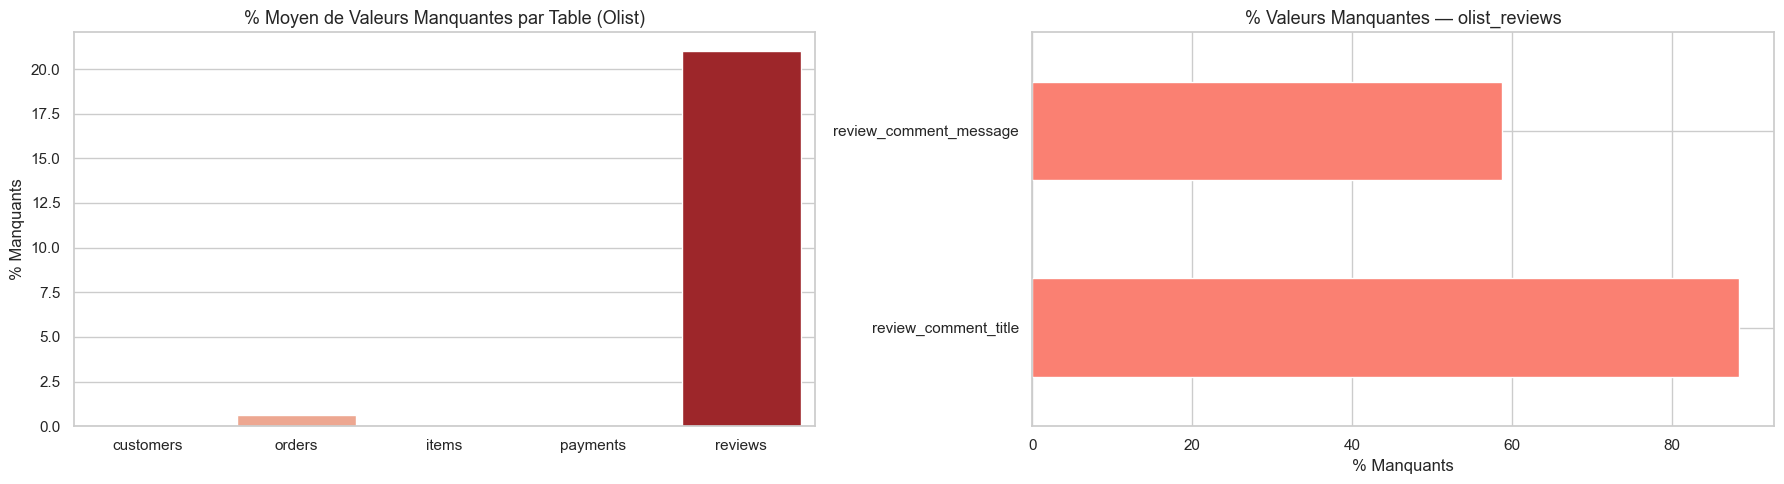

✅ Graphique sauvegardé : audit_missing_values.png


In [31]:
# ============================================================
# HEATMAP DES VALEURS MANQUANTES — OLIST
# ============================================================

# Fusion des tables Olist pour visualisation globale
olist_all = pd.concat([
    olist_customers.isnull().mean() * 100,
    olist_orders.isnull().mean() * 100,
    olist_order_items.isnull().mean() * 100,
    olist_payments.isnull().mean() * 100,
    olist_reviews.isnull().mean() * 100,
], keys=['customers', 'orders', 'items', 'payments', 'reviews'])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- Graphique 1 : % manquants par table Olist ---
olist_missing_by_table = pd.DataFrame({
    'Table'    : ['customers', 'orders', 'items', 'payments', 'reviews'],
    'Manquants': [
        olist_customers.isnull().mean().mean() * 100,
        olist_orders.isnull().mean().mean() * 100,
        olist_order_items.isnull().mean().mean() * 100,
        olist_payments.isnull().mean().mean() * 100,
        olist_reviews.isnull().mean().mean() * 100,
    ]
})

sns.barplot(data=olist_missing_by_table, x='Table', y='Manquants', ax=axes[0], palette='Reds')
axes[0].set_title('% Moyen de Valeurs Manquantes par Table (Olist)', fontsize=13)
axes[0].set_ylabel('% Manquants')
axes[0].set_xlabel('')

# --- Graphique 2 : % manquants colonnes Reviews (la plus impactée) ---
reviews_missing = (olist_reviews.isnull().mean() * 100).sort_values(ascending=False)
reviews_missing[reviews_missing > 0].plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('% Valeurs Manquantes — olist_reviews', fontsize=13)
axes[1].set_xlabel('% Manquants')

plt.tight_layout()
plt.savefig('audit_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : audit_missing_values.png")

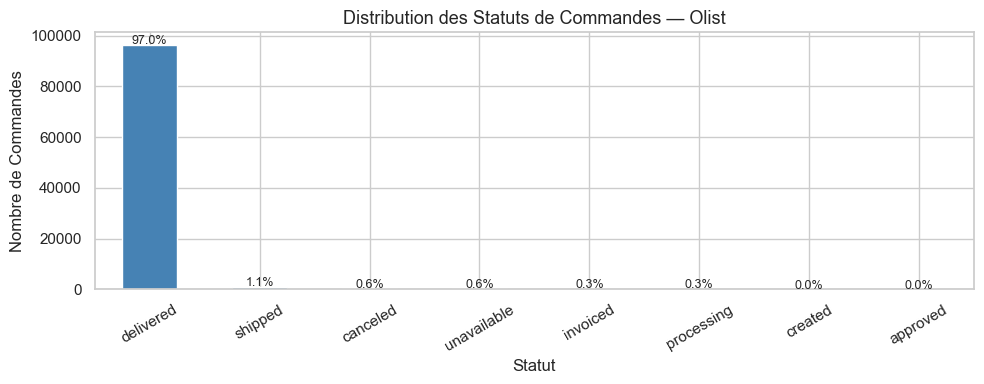

In [32]:
# ============================================================
# DISTRIBUTION DES STATUTS DE COMMANDES OLIST
# Permet de savoir quelle proportion de commandes est exploitable
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

# Comptage et tri des statuts
order_status_counts = olist_orders['order_status'].value_counts()

order_status_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution des Statuts de Commandes — Olist', fontsize=13)
ax.set_xlabel('Statut')
ax.set_ylabel('Nombre de Commandes')
ax.tick_params(axis='x', rotation=30)

# Annotation des pourcentages
total = order_status_counts.sum()
for i, v in enumerate(order_status_counts):
    ax.text(i, v + 100, f"{v/total*100:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('audit_order_status.png', dpi=150, bbox_inches='tight')
plt.show()

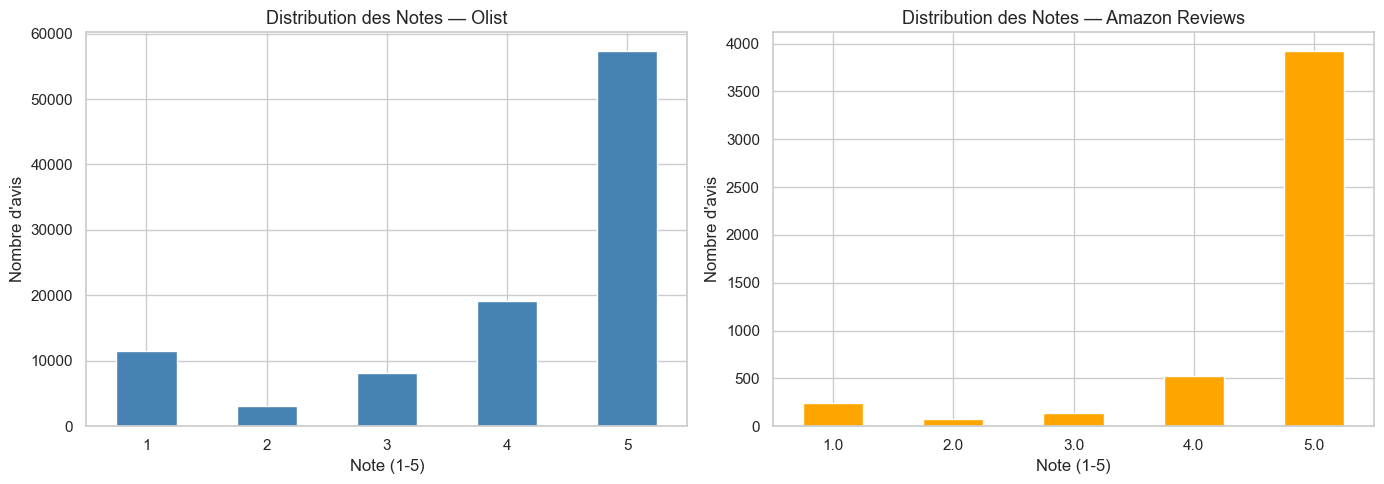

In [33]:
# ============================================================
# DISTRIBUTION DES NOTES OLIST ET AMAZON
# Première vue sur la satisfaction client
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Olist review scores
olist_reviews['review_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribution des Notes — Olist', fontsize=13)
axes[0].set_xlabel('Note (1-5)')
axes[0].set_ylabel('Nombre d\'avis')
axes[0].tick_params(axis='x', rotation=0)

# Amazon overall ratings
if 'overall' in amazon_reviews.columns:
    amazon_reviews['overall'].value_counts().sort_index().plot(
        kind='bar', ax=axes[1], color='orange', edgecolor='white'
    )
    axes[1].set_title('Distribution des Notes — Amazon Reviews', fontsize=13)
    axes[1].set_xlabel('Note (1-5)')
    axes[1].set_ylabel('Nombre d\'avis')
    axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('audit_review_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Synthèse du Data Audit

> Tableau récapitulatif des problèmes identifiés et actions prévues en Phase 3 (ETL).

In [35]:
# ============================================================
# RAPPORT QUALITÉ SYNTHÉTIQUE
# Récapitule les problèmes détectés et les actions ETL prévues
# ============================================================

quality_report = pd.DataFrame([
    {
        'Table'         : 'olist_orders',
        'Problème'      : 'Dates de livraison manquantes pour commandes non livrées',
        'Colonnes'      : 'order_delivered_customer_date, order_delivered_carrier_date',
        'Sévérité'      : 'Moyenne',
        'Action ETL'    : 'Filtrer sur order_status = "delivered" pour les analyses livraison'
    },
    {
        'Table'         : 'olist_reviews',
        'Problème'      : 'Commentaires textuels manquants (~60% des avis)',
        'Colonnes'      : 'review_comment_title, review_comment_message',
        'Sévérité'      : 'Faible',
        'Action ETL'    : 'Utiliser uniquement review_score (numérique) pour les modèles'
    },
    {
        'Table'         : 'instacart_orders',
        'Problème'      : 'days_since_prior_order = NaN pour la 1ère commande client',
        'Colonnes'      : 'days_since_prior_order',
        'Sévérité'      : 'Normale (attendue)',
        'Action ETL'    : 'Imputer par 0 ou flag "first_order" selon l\'usage'
    },
    {
        'Table'         : 'olist_customers',
        'Problème'      : 'customer_id ≠ customer_unique_id (un client peut avoir plusieurs customer_id)',
        'Colonnes'      : 'customer_id, customer_unique_id',
        'Sévérité'      : 'Haute',
        'Action ETL'    : 'Toujours agréger par customer_unique_id pour éviter les doublons clients'
    },
    {
        'Table'         : 'olist_payments',
        'Problème'      : 'Plusieurs lignes par order_id (paiements fractionnés)',
        'Colonnes'      : 'payment_sequential',
        'Sévérité'      : 'Moyenne',
        'Action ETL'    : 'Agréger par order_id : sum(payment_value) pour obtenir le montant total'
    },
])

# Coloriser le tableau par sévérité
def color_severity(val):
    colors = {
        'Haute'             : 'background-color: #ffcccc',
        'Moyenne'           : 'background-color: #fff0cc',
        'Faible'            : 'background-color: #ccffcc',
        'Normale (attendue)': 'background-color: #cce5ff'
    }
    return colors.get(val, '')

styled_report = quality_report.style.map(
    color_severity,
    subset=['Sévérité']
)
display(styled_report)

# Export CSV
quality_report.to_csv('data_quality_report.csv', index=False)
print("\nRapport qualité exporté : data_quality_report.csv")

,Table,Problème,Colonnes,Sévérité,Action ETL
0,olist_orders,Dates de livraison manquantes pour commandes non livrées,"order_delivered_customer_date, order_delivered_carrier_date",Moyenne,"Filtrer sur order_status = ""delivered"" pour les analyses livraison"
1,olist_reviews,Commentaires textuels manquants (~60% des avis),"review_comment_title, review_comment_message",Faible,Utiliser uniquement review_score (numérique) pour les modèles
2,instacart_orders,days_since_prior_order = NaN pour la 1ère commande client,days_since_prior_order,Normale (attendue),"Imputer par 0 ou flag ""first_order"" selon l'usage"
3,olist_customers,customer_id ≠ customer_unique_id (un client peut avoir plusieurs customer_id),"customer_id, customer_unique_id",Haute,Toujours agréger par customer_unique_id pour éviter les doublons clients
4,olist_payments,Plusieurs lignes par order_id (paiements fractionnés),payment_sequential,Moyenne,Agréger par order_id : sum(payment_value) pour obtenir le montant total



Rapport qualité exporté : data_quality_report.csv


---
## 6. Conclusion Phase 2

### Ce qui a été accompli
- ✅ Chargement de tous les datasets (Olist × 6 tables, Instacart × 5 tables, Amazon Reviews)
- ✅ Data Dictionary complet (colonnes, types, descriptions métier)
- ✅ Data Audit : valeurs manquantes, doublons, types, statistiques descriptives
- ✅ Visualisations qualité (missing values, statuts, distributions notes)
- ✅ Rapport qualité avec actions ETL planifiées

### Livrables produits
- `data_dictionary.csv` — Dictionnaire de données complet
- `data_quality_report.csv` — Rapport qualité avec actions correctives
- `audit_missing_values.png` — Heatmap valeurs manquantes
- `audit_order_status.png` — Distribution statuts commandes
- `audit_review_distribution.png` — Distribution des notes

### Prochaine étape → Phase 3 : ETL
Nettoyage, jointures, création des variables métier, construction du dataset analytique final.